In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, confusion_matrix
from pathlib import Path


In [15]:
# Configuración de visualización
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)


In [16]:
# ============================================
# 1. CARGA DE DATOS
# ============================================

# Ruta del archivo (ajústala si es necesario)
file_path = Path('C:/Users/leona/OneDrive/Escritorio/nuevoFINAL/Machine-learning/src/data/raw/stock_raw.csv')

df = pd.read_csv(file_path)

print("=== DATASET CARGADO ===")
print("Dimensiones:", df.shape)
print("\nPrimeras 5 filas:")
print(df.head())


=== DATASET CARGADO ===
Dimensiones: (91250, 15)

Primeras 5 filas:
         Date SKU_ID Warehouse_ID Supplier_ID Region  Units_Sold  \
0  2024-01-01  SKU_1         WH_1       SUP_8   West          10   
1  2024-01-02  SKU_1         WH_1       SUP_8   West          17   
2  2024-01-03  SKU_1         WH_1       SUP_8  North          35   
3  2024-01-04  SKU_1         WH_1       SUP_8  South          24   
4  2024-01-05  SKU_1         WH_1       SUP_8   West          21   

   Inventory_Level  Supplier_Lead_Time_Days  Reorder_Point  Order_Quantity  \
0              592                       14            379               0   
1              575                       14            379               0   
2              540                       14            379               0   
3              516                       14            379               0   
4              495                       14            379               0   

   Unit_Cost  Unit_Price  Promotion_Flag  Stockout_Fla

In [17]:
# ============================================
# 2. SELECCIÓN DE VARIABLES FINALES
# ============================================

# Identificamos columnas numéricas para el análisis
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

print("\n=== COLUMNAS NUMÉRICAS DISPONIBLES ===")
for i, col in enumerate(numeric_cols):
    print(f"{i}: {col}")

# Seleccionamos todas las columnas numéricas para el análisis
# (excepto SKU_ID, Warehouse_ID, Supplier_ID si son numéricos pero categóricos)
vars_finales = [col for col in numeric_cols if col not in ['SKU_ID', 'Warehouse_ID', 'Supplier_ID']]

# Si SKU_ID, Warehouse_ID, Supplier_ID no son numéricos, usar todas
if not vars_finales:
    vars_finales = numeric_cols

print(f"\n Variables seleccionadas ({len(vars_finales)}): {vars_finales}")

df_model = df[vars_finales].copy()

print("\n=== DATASET FINAL ===")
print("Dimensiones:", df_model.shape)
print("Variables:", list(df_model.columns))
print("\nPrimeras 5 filas:")
print(df_model.head())



=== COLUMNAS NUMÉRICAS DISPONIBLES ===
0: Units_Sold
1: Inventory_Level
2: Supplier_Lead_Time_Days
3: Reorder_Point
4: Order_Quantity
5: Unit_Cost
6: Unit_Price
7: Promotion_Flag
8: Stockout_Flag
9: Demand_Forecast

 Variables seleccionadas (10): ['Units_Sold', 'Inventory_Level', 'Supplier_Lead_Time_Days', 'Reorder_Point', 'Order_Quantity', 'Unit_Cost', 'Unit_Price', 'Promotion_Flag', 'Stockout_Flag', 'Demand_Forecast']

=== DATASET FINAL ===
Dimensiones: (91250, 10)
Variables: ['Units_Sold', 'Inventory_Level', 'Supplier_Lead_Time_Days', 'Reorder_Point', 'Order_Quantity', 'Unit_Cost', 'Unit_Price', 'Promotion_Flag', 'Stockout_Flag', 'Demand_Forecast']

Primeras 5 filas:
   Units_Sold  Inventory_Level  Supplier_Lead_Time_Days  Reorder_Point  \
0          10              592                       14            379   
1          17              575                       14            379   
2          35              540                       14            379   
3          24           

In [18]:
# ============================================
# 3. MEDIDAS DE TENDENCIA CENTRAL Y DISPERSIÓN
# ============================================

print("\n=== MEDIDAS DE TENDENCIA CENTRAL Y DISPERSIÓN ===")
estadisticos = df_model.describe().T
# Añadir varianza y desviación estándar (describe ya incluye std)
estadisticos['varianza'] = df_model.var()
estadisticos['rango'] = df_model.max() - df_model.min()
print(estadisticos.round(4))


=== MEDIDAS DE TENDENCIA CENTRAL Y DISPERSIÓN ===
                           count      mean       std     min     25%     50%  \
Units_Sold               91250.0   20.0546    9.0686    0.00   13.00   20.00   
Inventory_Level          91250.0  471.5223  133.4880  168.00  370.00  461.00   
Supplier_Lead_Time_Days  91250.0    7.9840    3.9079    2.00    4.00    8.00   
Reorder_Point            91250.0  300.0680   54.8799  201.00  252.00  300.00   
Order_Quantity           91250.0   19.2725   82.3408    0.00    0.00    0.00   
Unit_Cost                91250.0   12.2033    4.5750    5.02    8.18   11.99   
Unit_Price               91250.0   18.2618    7.1211    6.95   12.00   18.18   
Promotion_Flag           91250.0    0.1016    0.3021    0.00    0.00    0.00   
Stockout_Flag            91250.0    0.0000    0.0000    0.00    0.00    0.00   
Demand_Forecast          91250.0   20.0820    9.5040    0.00   12.95   19.95   

                            75%     max    varianza   rango  
Units_

In [19]:
# ============================================
# 4. CALIDAD DE DATOS: NULOS E IMPUTACIÓN
# ============================================

print("\n=== NULOS ANTES DE IMPUTACIÓN ===")
nulos_antes = df_model.isnull().sum()
print(nulos_antes[nulos_antes > 0] if any(nulos_antes > 0) else "No hay valores nulos.")

# Imputación con mediana (más robusta para outliers)
df_model_imputed = df_model.fillna(df_model.median())

print("\n=== NULOS DESPUÉS DE IMPUTACIÓN ===")
print(f"Total nulos restantes: {df_model_imputed.isnull().sum().sum()}")



=== NULOS ANTES DE IMPUTACIÓN ===
No hay valores nulos.

=== NULOS DESPUÉS DE IMPUTACIÓN ===
Total nulos restantes: 0



=== DETECCIÓN DE OUTLIERS ===


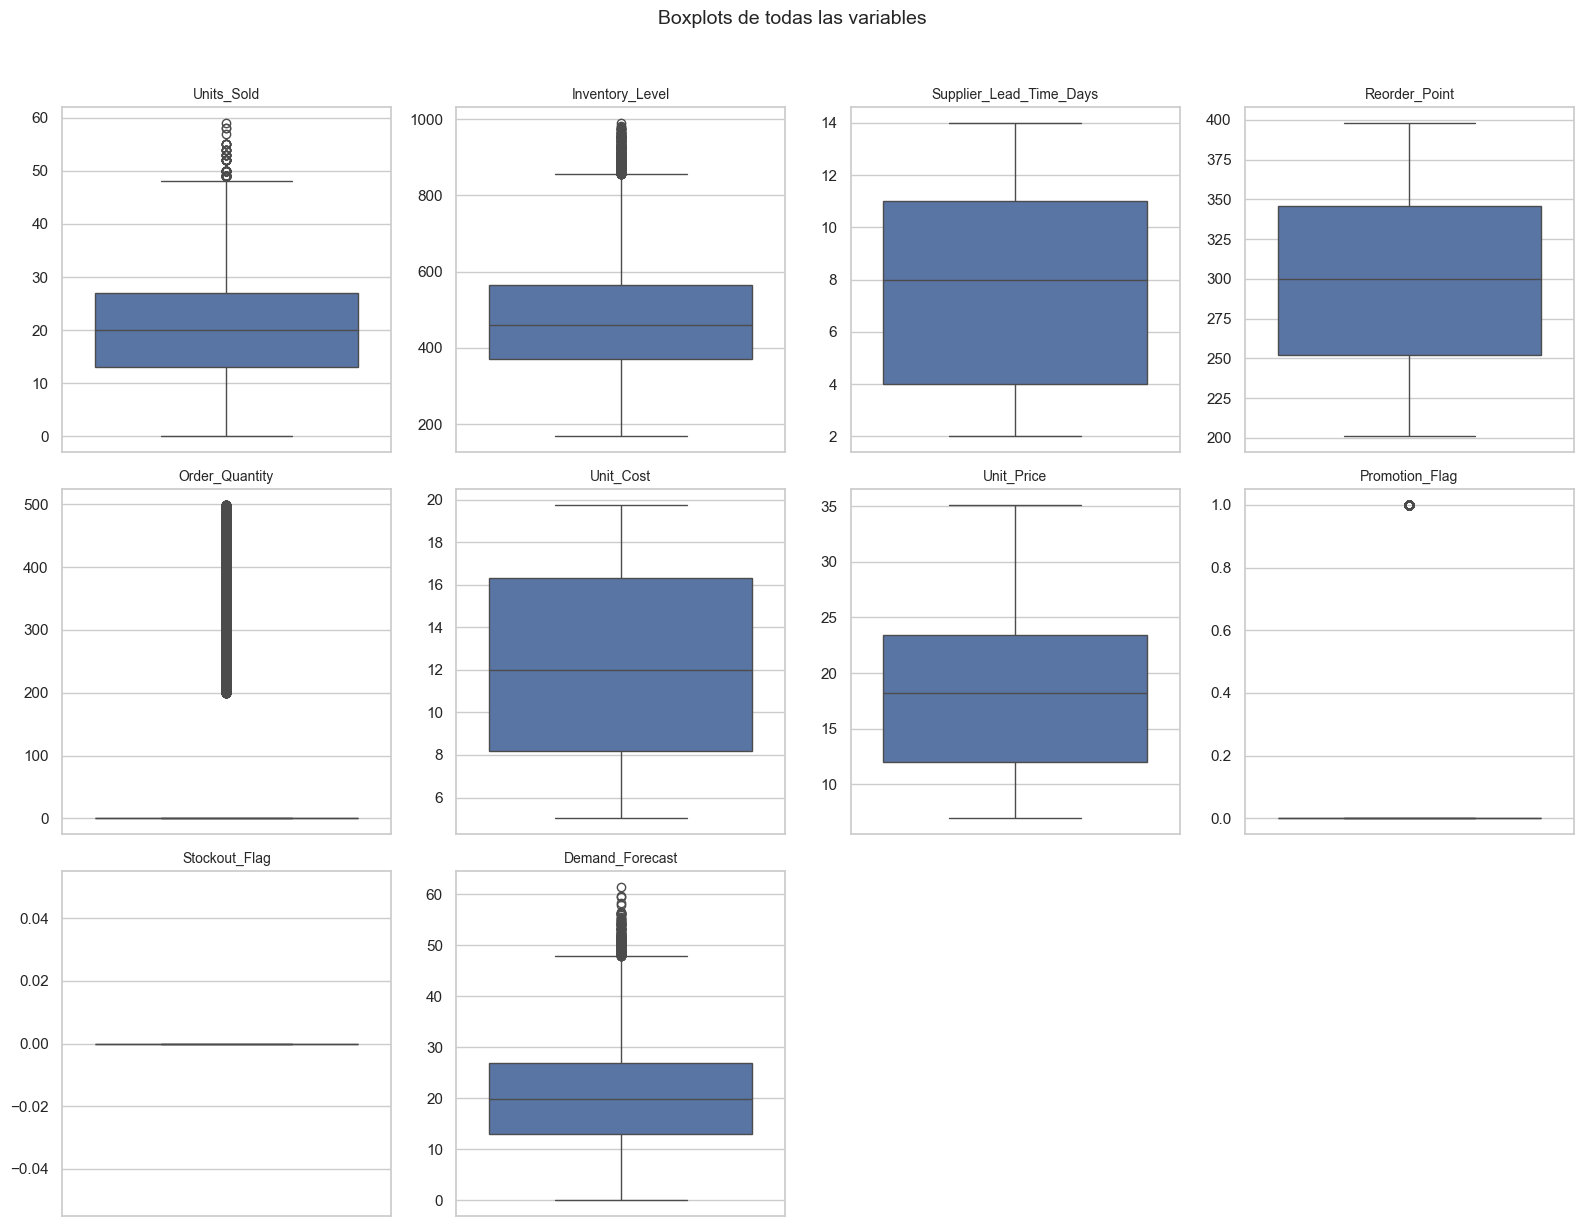


Outliers por variable (|z| > 3):
  Units_Sold: 161 outliers (0.18%)
  Inventory_Level: 156 outliers (0.17%)
  Supplier_Lead_Time_Days: 0 outliers (0.00%)
  Reorder_Point: 0 outliers (0.00%)
  Order_Quantity: 3922 outliers (4.30%)
  Unit_Cost: 0 outliers (0.00%)
  Unit_Price: 0 outliers (0.00%)
  Promotion_Flag: 0 outliers (0.00%)
  Stockout_Flag: 0 outliers (0.00%)
  Demand_Forecast: 151 outliers (0.17%)


In [20]:
# ============================================
# 5. DETECCIÓN DE OUTLIERS (Boxplots + Z-score)
# ============================================

print("\n=== DETECCIÓN DE OUTLIERS ===")

# Boxplots de todas las variables numéricas
n_vars = len(vars_finales)
n_cols = 4
n_rows = (n_vars + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))
axes = axes.flatten() if n_rows > 1 else [axes] if n_vars > 1 else [axes]

for i, col in enumerate(vars_finales):
    sns.boxplot(y=df_model_imputed[col], ax=axes[i])
    axes[i].set_title(col, fontsize=10)
    axes[i].set_ylabel('')

# Ocultar ejes vacíos
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Boxplots de todas las variables", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

# Z-score para detección de outliers
z_scores = np.abs(stats.zscore(df_model_imputed))
outliers_count = (z_scores > 3).sum(axis=0)

print("\nOutliers por variable (|z| > 3):")
for col, count in zip(vars_finales, outliers_count):
    print(f"  {col}: {count} outliers ({count/len(df_model_imputed)*100:.2f}%)")


=== MATRIZ DE CORRELACIÓN (vs target) ===
Variable objetivo (target): Inventory_Level
Inventory_Level            1.000000
Reorder_Point              0.395432
Order_Quantity             0.290513
Supplier_Lead_Time_Days    0.013397
Unit_Cost                  0.003211
Unit_Price                -0.004462
Promotion_Flag            -0.013263
Demand_Forecast           -0.059657
Units_Sold                -0.064285
Stockout_Flag                   NaN
Name: Inventory_Level, dtype: float64

=== MATRIZ DE COVARIANZA (primeras 5x5) ===
                         Units_Sold  Inventory_Level  Supplier_Lead_Time_Days  \
Units_Sold                  82.2395         -77.8203                   0.0180   
Inventory_Level            -77.8203       17819.0466                   6.9887   
Supplier_Lead_Time_Days      0.0180           6.9887                  15.2719   
Reorder_Point               -0.8114        2896.8585                   5.7572   
Order_Quantity              51.7681        3193.1737             

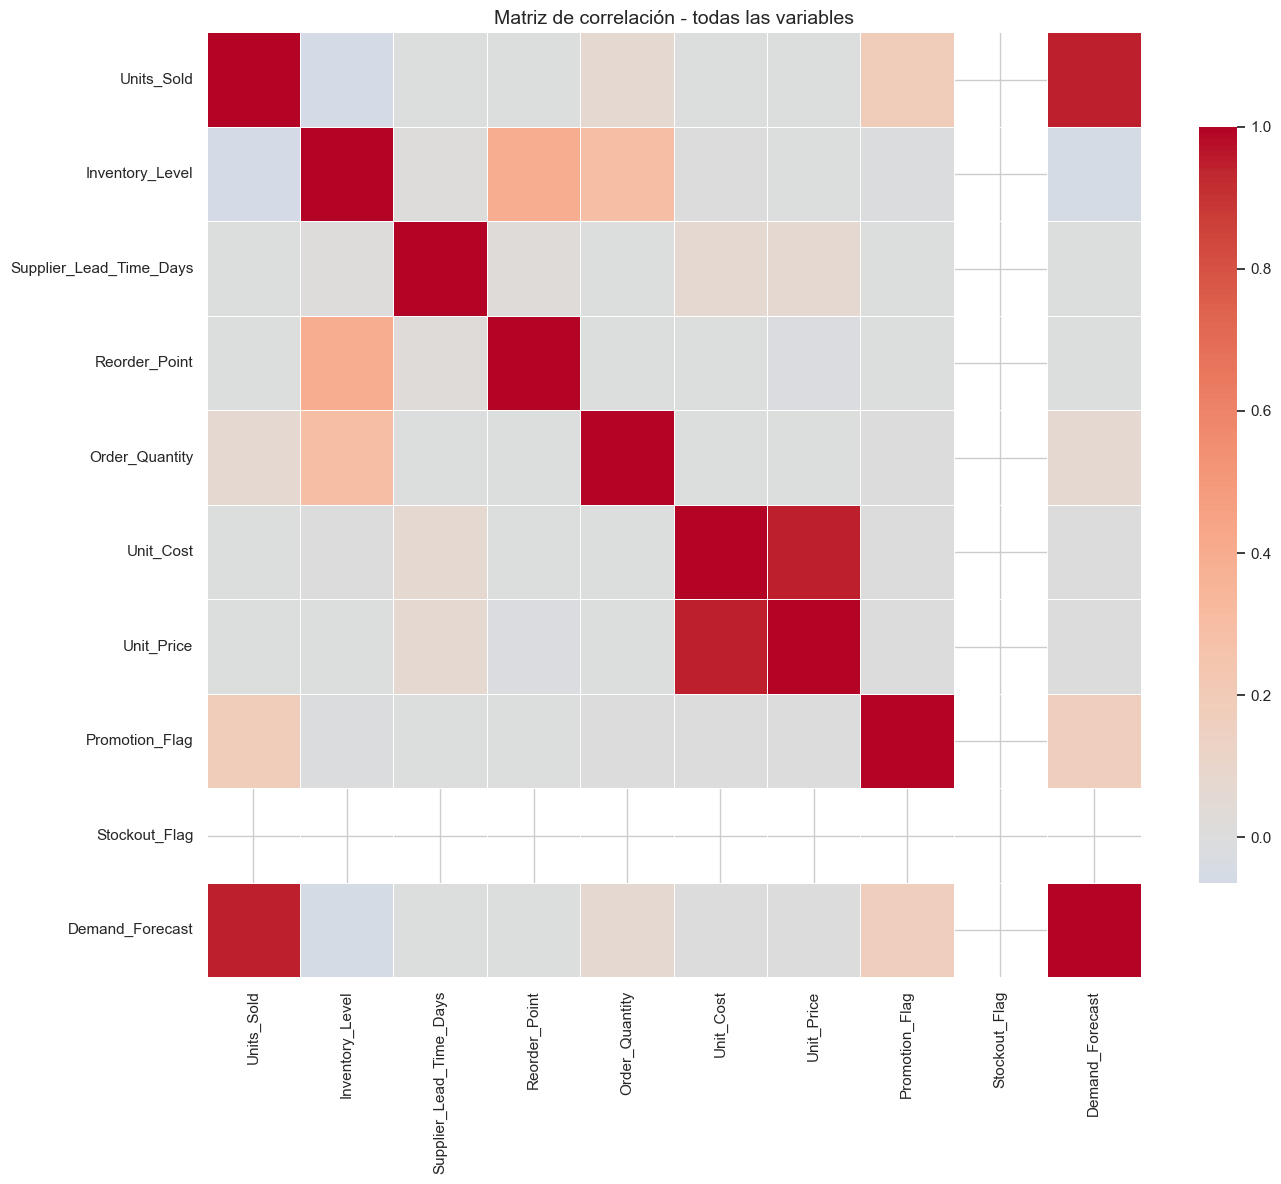

In [21]:
# ============================================
# 6. ANÁLISIS MULTIVARIADO
# ============================================

print("\n=== MATRIZ DE CORRELACIÓN (vs target) ===")

# Definir target (variable a predecir)
target_col = 'Inventory_Level'  # Nivel de inventario
print(f"Variable objetivo (target): {target_col}")

if target_col in df_model_imputed.columns:
    corr_matrix = df_model_imputed.corr()
    target_corr = corr_matrix[target_col].sort_values(ascending=False)
    print(target_corr)
    
    # Matriz de covarianza
    print("\n=== MATRIZ DE COVARIANZA (primeras 5x5) ===")
    cov_matrix = df_model_imputed.cov()
    print(cov_matrix.iloc[:5, :5].round(4))
    
    # Heatmap de correlación completa
    plt.figure(figsize=(14, 12))
    sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', center=0, 
                linewidths=0.5, cbar_kws={"shrink": 0.8})
    plt.title("Matriz de correlación - todas las variables", fontsize=14)
    plt.tight_layout()
    plt.show()
else:
    print(f"⚠️ La columna '{target_col}' no existe en el dataset.")
    print(f"Columnas disponibles: {df_model_imputed.columns.tolist()}")


=== TOP 4 FEATURES CON MAYOR CORRELACIÓN CON 'Inventory_Level' ===
['Reorder_Point', 'Order_Quantity', 'Units_Sold', 'Demand_Forecast']


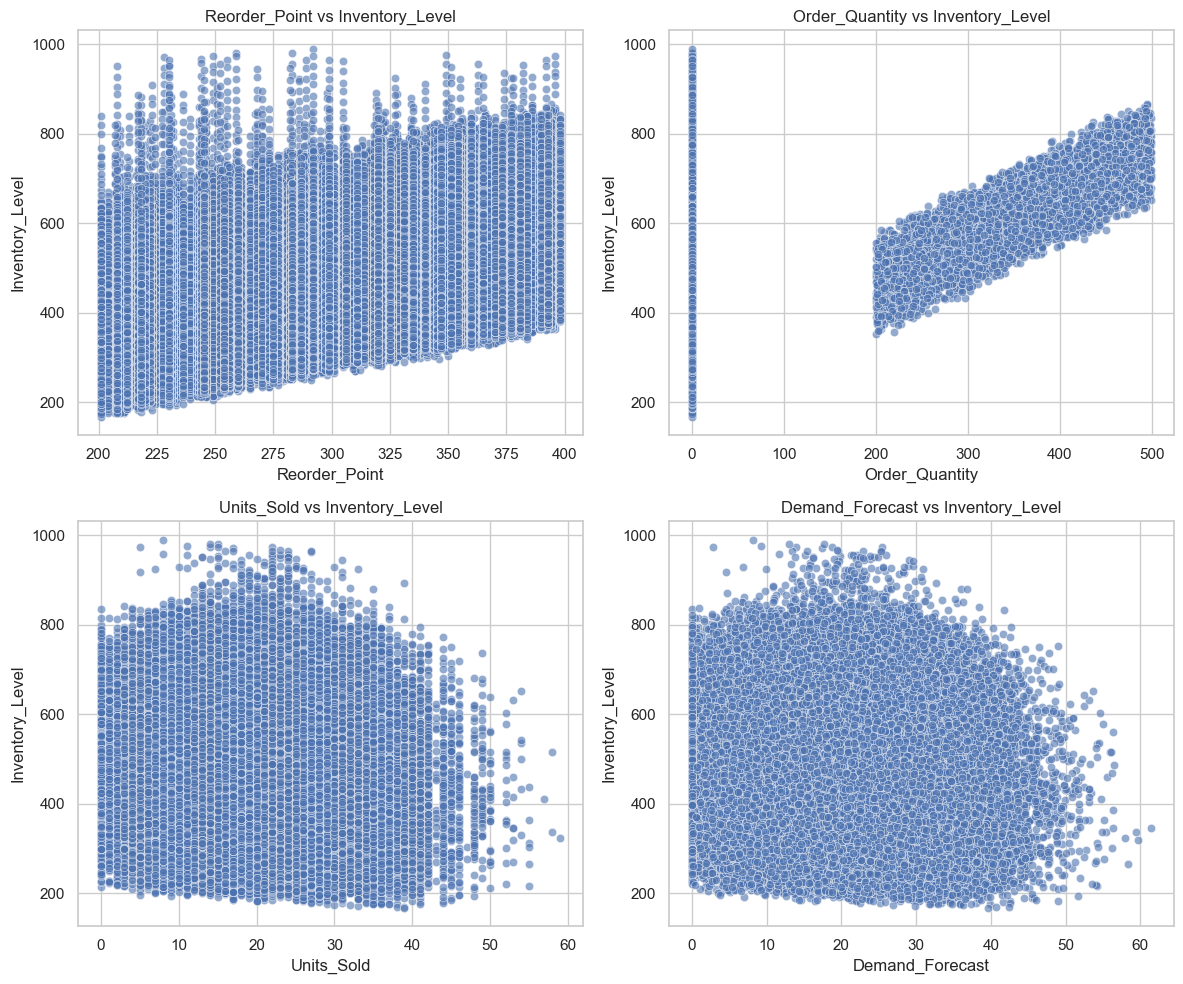

In [22]:
# ============================================
# 7. GRÁFICOS DE DISPERSIÓN (predictoras vs target)
# ============================================

if target_col in df_model_imputed.columns:
    # Seleccionar top features con mayor correlación (absoluta) con el target
    corr_abs = target_corr.drop(target_col).abs().sort_values(ascending=False)
    top_features = corr_abs.head(4).index.tolist()
    
    print(f"\n=== TOP 4 FEATURES CON MAYOR CORRELACIÓN CON '{target_col}' ===")
    print(top_features)
    
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    axes = axes.flatten()
    
    for i, col in enumerate(top_features):
        sns.scatterplot(x=df_model_imputed[col],
                        y=df_model_imputed[target_col],
                        ax=axes[i],
                        alpha=0.6)
        axes[i].set_title(f'{col} vs {target_col}', fontsize=12)
        axes[i].set_xlabel(col)
        axes[i].set_ylabel(target_col)
    
    plt.tight_layout()
    plt.show()
else:
    print(f"\n⚠️ No se pueden generar gráficos de dispersión: '{target_col}' no encontrado.")


=== PREPARACIÓN PARA RED NEURONAL (MLPClassifier) ===
Distribución de categorías:
  Low: 30835 (33.8%)
  Medium: 30138 (33.0%)
  High: 30277 (33.2%)

Percentiles usados: 33% = 399.00, 66% = 524.00

Tamaño de entrenamiento: (73000, 9)
Tamaño de prueba: (18250, 9)

=== ENTRENANDO MLPClassifier ===
 Modelo entrenado en 20 iteraciones
Pérdida final: 0.9730

=== REPORTE DE CLASIFICACIÓN (MLP) ===
              precision    recall  f1-score   support

         Low       0.50      0.61      0.55      6167
      Medium       0.48      0.70      0.57      6028
        High       0.41      0.14      0.21      6055

    accuracy                           0.48     18250
   macro avg       0.47      0.48      0.44     18250
weighted avg       0.47      0.48      0.44     18250



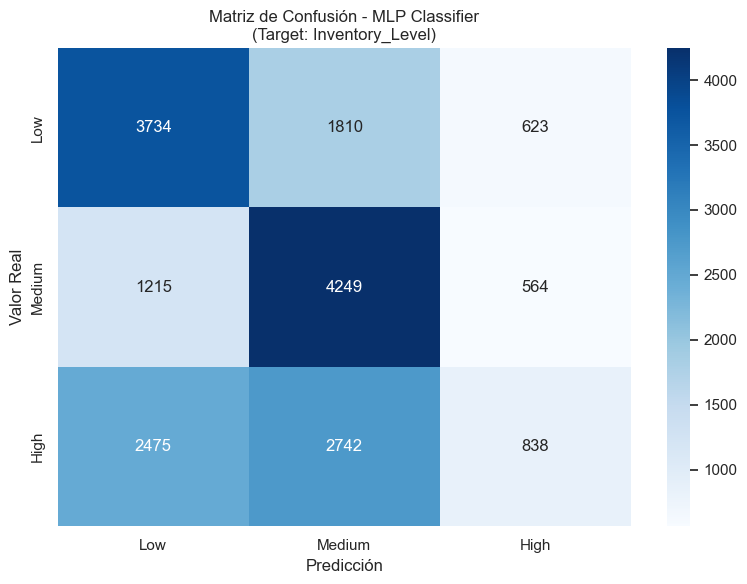


 Precisión del modelo: 0.4833 (48.33%)


In [23]:
# ============================================
# 8. PREPARACIÓN PARA RED NEURONAL (MLPClassifier) - VERSIÓN CORREGIDA
# ============================================

print("\n=== PREPARACIÓN PARA RED NEURONAL (MLPClassifier) ===")

if target_col in df_model_imputed.columns:
    # Separar features (X) y target (y)
    X = df_model_imputed.drop(target_col, axis=1)
    y = df_model_imputed[target_col]
    
    # Discretizar target en 3 categorías (Bajo, Medio, Alto)
    # Usando percentiles para una distribución balanceada
    percentiles = y.quantile([0.33, 0.66]).values
    labels = ['Low', 'Medium', 'High']
    y_discretizado = pd.cut(y, bins=[-np.inf, percentiles[0], percentiles[1], np.inf], labels=labels)
    
    # Convertir a números para evitar problemas con MLP
    from sklearn.preprocessing import LabelEncoder
    le = LabelEncoder()
    y_encoded = le.fit_transform(y_discretizado)
    
    print(f"Distribución de categorías:")
    for i, label in enumerate(labels):
        count = (y_encoded == i).sum()
        print(f"  {label}: {count} ({count/len(y_encoded)*100:.1f}%)")
    print(f"\nPercentiles usados: 33% = {percentiles[0]:.2f}, 66% = {percentiles[1]:.2f}")
    
    # Escalar características
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    # División en train/test
    X_train, X_test, y_train, y_test = train_test_split(
        X_scaled, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
    )
    
    print(f"\nTamaño de entrenamiento: {X_train.shape}")
    print(f"Tamaño de prueba: {X_test.shape}")
    
    # Entrenar red neuronal
    print("\n=== ENTRENANDO MLPClassifier ===")
    mlp = MLPClassifier(
        hidden_layer_sizes=(50, 25), 
        max_iter=500, 
        random_state=42,
        early_stopping=True,
        validation_fraction=0.1,
        verbose=False
    )
    mlp.fit(X_train, y_train)
    
    print(f" Modelo entrenado en {mlp.n_iter_} iteraciones")
    print(f"Pérdida final: {mlp.loss_:.4f}")
    
    # Predicciones y evaluación
    y_pred = mlp.predict(X_test)
    
    print("\n=== REPORTE DE CLASIFICACIÓN (MLP) ===")
    print(classification_report(y_test, y_pred, target_names=labels))
    
    # Matriz de confusión
    cm = confusion_matrix(y_test, y_pred, labels=[0, 1, 2])
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=labels,
                yticklabels=labels)
    plt.title('Matriz de Confusión - MLP Classifier\n(Target: Inventory_Level)', fontsize=12)
    plt.xlabel('Predicción')
    plt.ylabel('Valor Real')
    plt.tight_layout()
    plt.show()
    
    # Precisión del modelo
    accuracy = mlp.score(X_test, y_test)
    print(f"\n Precisión del modelo: {accuracy:.4f} ({accuracy*100:.2f}%)")
    
else:
    print(f" No se puede ejecutar el MLP: '{target_col}' no encontrado.")

In [24]:
# ============================================
# 9. RESUMEN FINAL
# ============================================

print("\n" + "="*50)
print("RESUMEN DEL ANÁLISIS")
print("="*50)
print(f" Dataset original: {df.shape[0]} filas, {df.shape[1]} columnas")
print(f" Variables numéricas analizadas: {len(vars_finales)}")
print(f" Variable objetivo: {target_col}")
print(f" Total outliers detectados: {outliers_count.sum()}")
print(f" Modelo MLP: Capas ocultas (50, 25), {mlp.n_iter_} iteraciones")
print(f" Precisión del modelo: {accuracy:.4f} ({accuracy*100:.2f}%)" if target_col in df_model_imputed.columns else "❌ Modelo no ejecutado")
print("="*50)


RESUMEN DEL ANÁLISIS
 Dataset original: 91250 filas, 15 columnas
 Variables numéricas analizadas: 10
 Variable objetivo: Inventory_Level
 Total outliers detectados: 4390
 Modelo MLP: Capas ocultas (50, 25), 20 iteraciones
 Precisión del modelo: 0.4833 (48.33%)
